In [3]:
import pandas as pd

df = pd.read_csv("Shopping Mall Customer Segmentation Data .csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (15079, 5)


,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [4]:
# Check dataset information

df.info()

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB

Missing values:
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64


In [5]:
# Select features for customer segmentation

X = df[["Annual Income", "Spending Score"]]

print("Features selected for clustering:")
print(X.head())

print("\nShape:", X.shape)

Features selected for clustering:
   Annual Income  Spending Score
0         151479              89
1         185088              95
2          70912              76
3          55460              57
4         153752              76

Shape: (15079, 2)


In [6]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully!")
print(X_scaled[:5])

Features scaled successfully!
[[ 0.79881267  1.33705873]
 [ 1.44207552  1.54592857]
 [-0.74320756  0.88450743]
 [-1.03895267  0.2230863 ]
 [ 0.84231698  0.88450743]]


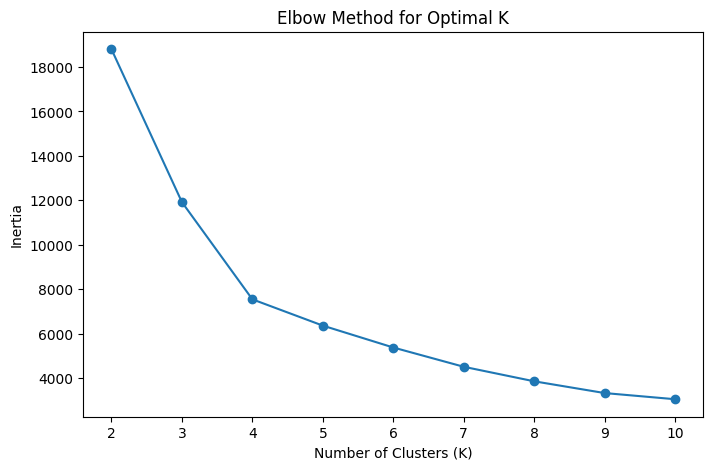

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

# Test different numbers of clusters
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [9]:
# Create and train the K-Means model

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

kmeans.fit(X_scaled)

print("K-Means model trained successfully!")
print("Number of clusters:", kmeans.n_clusters)

K-Means model trained successfully!
Number of clusters: 4


In [10]:
# Assign each customer to a cluster

df["Cluster"] = kmeans.labels_

print("Cluster labels assigned successfully!")

print("\nCustomer count in each cluster:")
print(df["Cluster"].value_counts().sort_index())

Cluster labels assigned successfully!

Customer count in each cluster:
Cluster
0    3862
1    3788
2    3780
3    3649
Name: count, dtype: int64


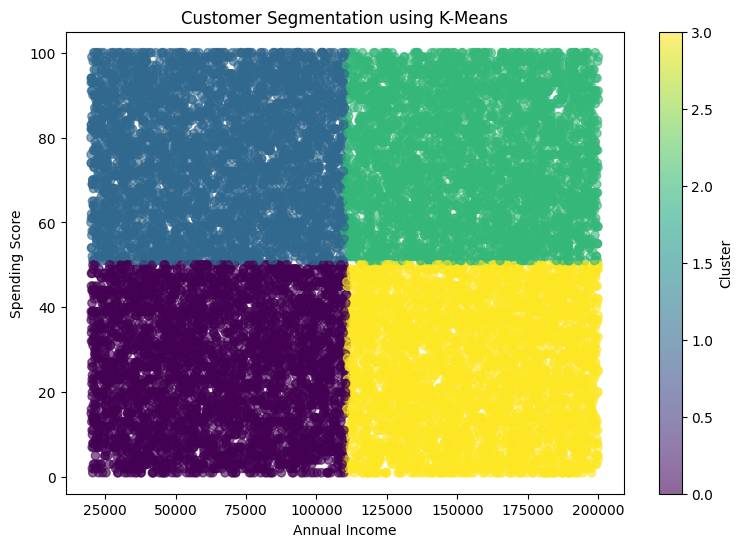

In [11]:
# Visualize customer clusters

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Annual Income"],
    df["Spending Score"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.colorbar(label="Cluster")

plt.show()

In [12]:
# Analyze the characteristics of each cluster

cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Annual Income",
    "Spending Score"
]].mean()

print(cluster_summary)

               Age  Annual Income  Spending Score
Cluster                                          
0        54.250906   65147.551787       25.788193
1        53.962777   64963.854541       75.503696
2        54.368254  155276.082275       75.115873
3        54.183338  156258.256783       25.577144


Task 4: Customer Segmentation using K-Means

Customer data was segmented using K-Means clustering based on Annual Income and Spending Score.

The features were standardized using StandardScaler.
The Elbow Method was used to select K = 4 clusters.
Customers were grouped into 4 segments and visualized using a scatter plot.
Cluster characteristics were analyzed using average age, income, and spending score.

Cluster 0: Low income and low spending
Cluster 1: Low income and high spending
Cluster 2: High income and high spending
Cluster 3: High income and low spending

Conclusion: K-Means helped identify four distinct customer segments based on income and spending behavior.